In [5]:
!pip install lime

In [6]:
import tensorflow as tf
import numpy as np
import PIL.Image
from skimage.io import imread
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
from lime import lime_image

%matplotlib inline

In [7]:
def LoadImage(file_path, model='VGG'):
    im = PIL.Image.open(file_path)
    if model == 'Inception':
        im = im.resize((299,299))
    else:
        im = im.resize((224,224))
    im = np.asarray(im)
    return im

def PreprocessVGGImage(im):
    im = tf.keras.applications.vgg16.preprocess_input(im)
    return im

def PreprocessInceptionImage(im):
    im = tf.keras.applications.inception_v3.preprocess_input(im)
    return im


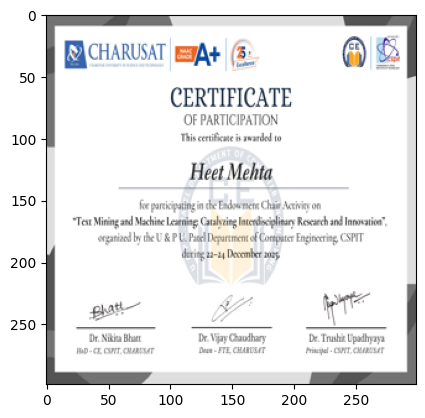

In [8]:
im_orig = LoadImage('download.jpg', model='Inception')

plt.imshow(im_orig)
plt.show()

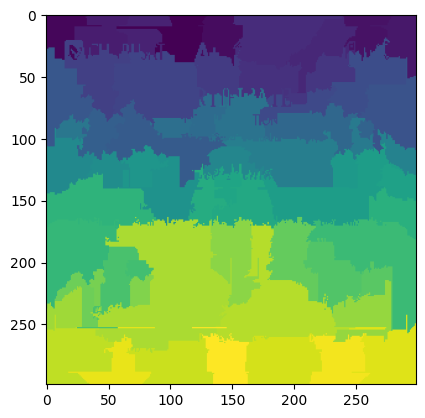

In [9]:
from skimage.segmentation import felzenszwalb, quickshift

segments = quickshift(im_orig,
                      kernel_size=4,
                      max_dist=200,
                      ratio=0.2,
                      rng=42)
plt.imshow(segments)
plt.show()

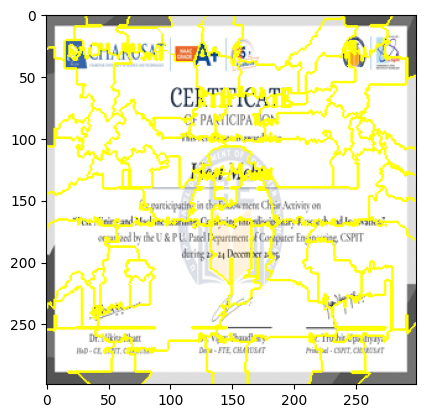

In [10]:
plt.imshow(mark_boundaries(im_orig, segments))
plt.show()

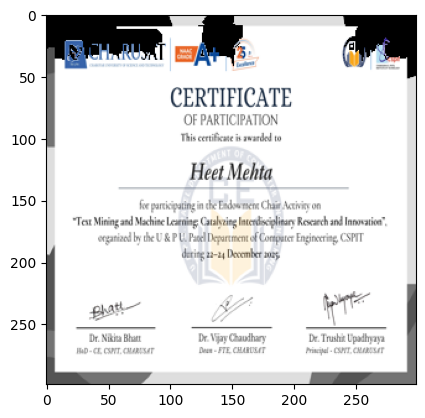

In [11]:
segmented_image = im_orig.copy()

# Isolate a few segments
segmented_image[segments == 1] = 0
segmented_image[segments == 2] = 0
segmented_image[segments == 3] = 0
segmented_image[segments == 4] = 0
segmented_image[segments == 5] = 0
segmented_image[segments == 6] = 0
plt.imshow(segmented_image)
plt.show()

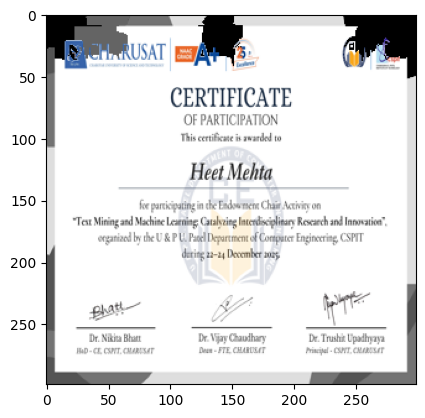

In [ ]:
# fudged_image = im_orig.copy()
# # Isolate a few segments
# fudged_image[segments == 1] = 0
# fudged_image[segments == 2] = 0
# fudged_image[segments == 3] = 0
# fudged_image[segments == 4] = 0
# fudged_image[segments == 5] = 0
# plt.imshow(fudged_image)
# plt.show()

plt.imshow(rotar)

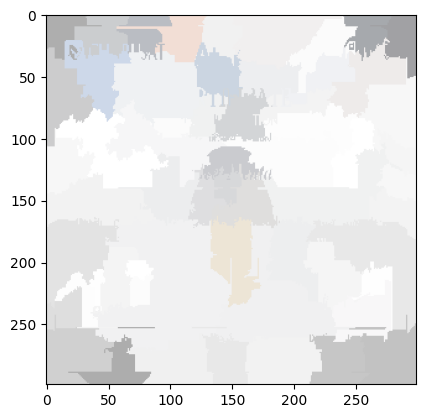

In [13]:
segmented_image = im_orig.copy()
# Replace superpixel with average of the pixel values
for x in np.unique(segments):
    segmented_image[segments == x] = (
        np.mean(im_orig[segments == x][:, 0]),
        np.mean(im_orig[segments == x][:, 1]),
        np.mean(im_orig[segments == x][:, 2]))

plt.imshow(segmented_image)
plt.show()

In [14]:
inception = tf.keras.applications.InceptionV3(
    include_top=True, weights='imagenet')
model = tf.keras.models.Model(inception.inputs, inception.output)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


Prediction class: 916


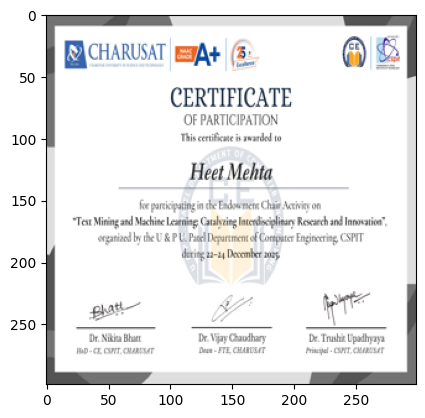

In [15]:
# Load the image
im_orig = LoadImage('download.jpg', model='Inception')
image = PreprocessInceptionImage(im_orig)

# Show the image
plt.imshow(im_orig)

predictions = model(np.array([image]))
prediction_class = np.argmax(predictions[0])

print("Prediction class: " + str(prediction_class))

In [16]:
# Create LIME explainer
explainer = lime_image.LimeImageExplainer()

# Define prediction function for LIME
def predict_fn(images):
    preprocessed = np.array([PreprocessInceptionImage(img) for img in images])
    return model.predict(preprocessed)

# Generate explanation
explanation = explainer.explain_instance(
    im_orig,
    predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=10
)

print("Explanation generated successfully!")
print("Top labels:", explanation.top_labels)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


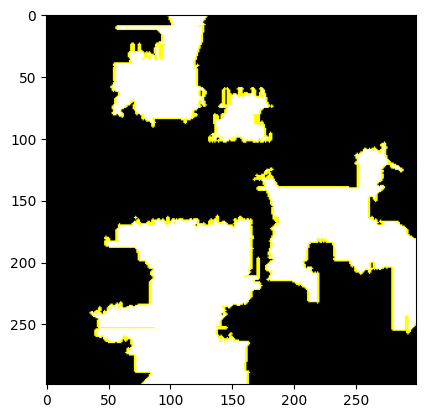

In [17]:
temp, mask = explanation.get_image_and_mask(label=explanation.top_labels[0],
                                            positive_only=False,
                                            num_features=10,
                                            hide_rest=True)
plt.imshow(mark_boundaries(temp, mask))
plt.show()